<a href="https://colab.research.google.com/github/Roshni-AngelAlex/MACHINE-LEARNING-LAB-24ADI003-/blob/main/MLLABEX10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MACHINE LEARNING**

**LAB EXPERIMENT 10**

**Recommendation Systems using Matrix Factorization**
**(SVD & NMF)**


**NAME : ROSHNI ANGEL A / ROLLNO: 24BAD101**

SCENARIO 1 – MATRIX FACTORIZATION USING SVD

Problem Statement

Use Singular Value Decomposition (SVD) to recommend movies based on latent user-item interactions.

Dataset (Kaggle – Public)
MovieLens Dataset
Dataset Link: https://www.kaggle.com/datasets/grouplens/movielens-100k


Target Variable:

Predicted ratings for unseen movies

Input Feature:

• User ID

• Movie ID

• Ratings



RMSE: 0.9336
MAE:  0.7365
movieId
423    3.509642
403    3.097894
732    2.971226
357    2.752628
385    2.605706
303    2.574760
470    2.475011
367    2.432600
582    2.409058
318    2.376752
Name: 1, dtype: float64


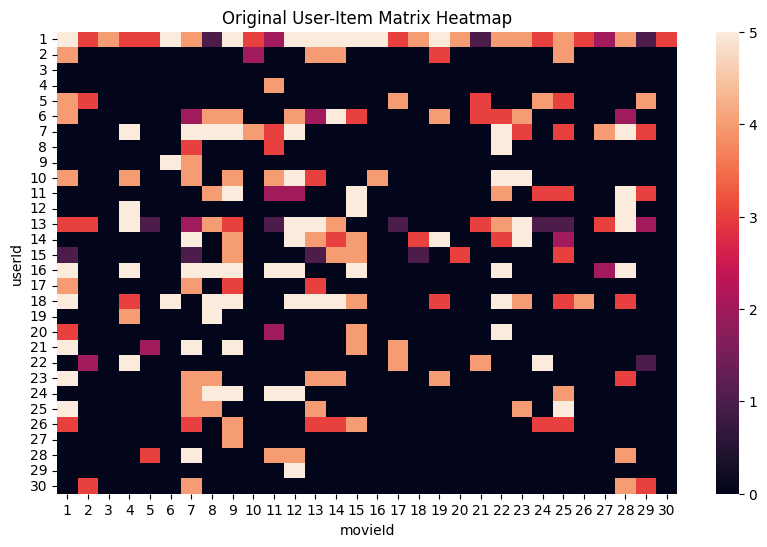

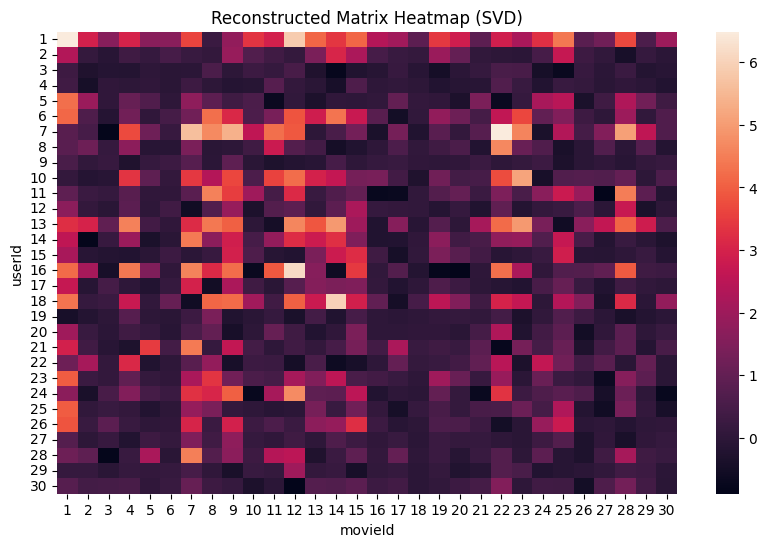

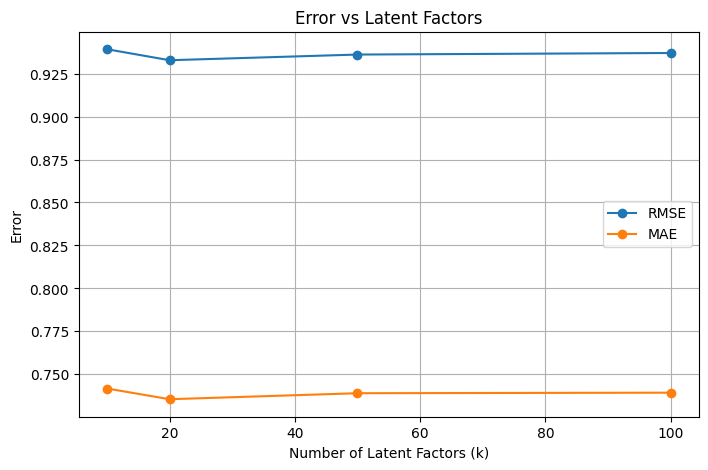

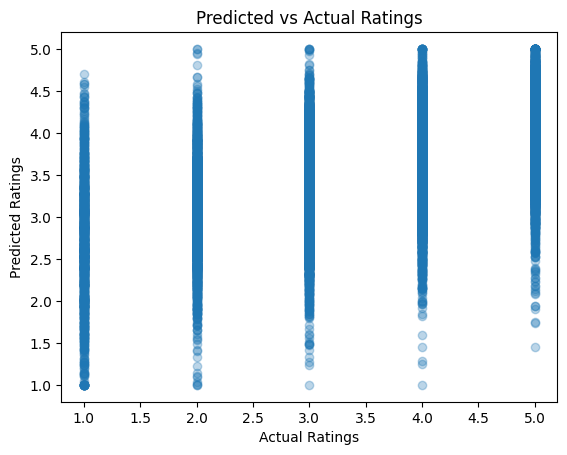

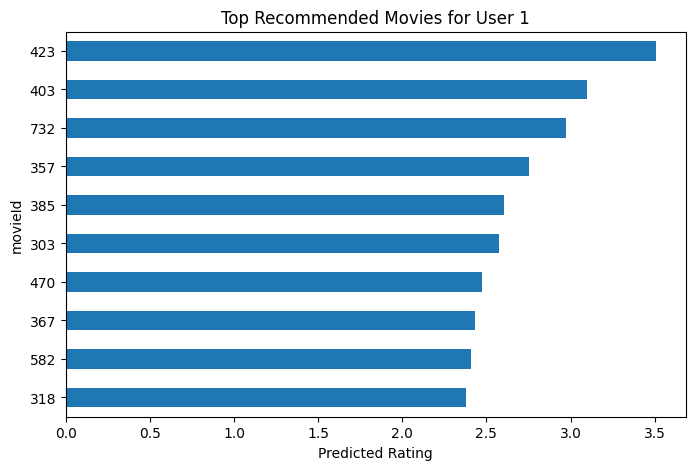

In [4]:
# SCENARIO 1 : SVD RECOMMENDER

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from surprise import Dataset, Reader, SVD, accuracy
from surprise.model_selection import train_test_split

# Load Dataset
ratings = pd.read_csv("u.data", sep="\t",
                      names=["userId","movieId","rating","timestamp"])
ratings = ratings.drop("timestamp", axis=1)

# Surprise Dataset
reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(ratings, reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# Train Model
model = SVD(n_factors=50)
model.fit(trainset)

# Predictions
predictions = model.test(testset)

# Evaluation
rmse = accuracy.rmse(predictions)
mae = accuracy.mae(predictions)


# User-Item Matrix
user_item = ratings.pivot(index="userId",
                          columns="movieId",
                          values="rating")

user_item_filled = user_item.fillna(0)

# Mean Centering
user_means = user_item_filled.mean(axis=1)
normalized = user_item_filled.sub(user_means, axis=0)


# SVD Decomposition

U, sigma, Vt = np.linalg.svd(normalized, full_matrices=False)

k = 50
U_k = U[:, :k]
sigma_k = np.diag(sigma[:k])
Vt_k = Vt[:k, :]

reconstructed = np.dot(np.dot(U_k, sigma_k), Vt_k)
reconstructed += user_means.values.reshape(-1,1)

reconstructed_df = pd.DataFrame(reconstructed,
                                index=user_item.index,
                                columns=user_item.columns)

# Top-N Recommendations

def recommend_movies(user_id, n=10):
    user_ratings = user_item.loc[user_id]
    preds = reconstructed_df.loc[user_id]

    unseen = user_ratings[user_ratings.isna()].index
    recs = preds[unseen].sort_values(ascending=False).head(n)
    return recs

top_recs = recommend_movies(1,10)
print(top_recs)


# VISUALIZATIONS

# 1️⃣ Heatmap: Original Matrix
plt.figure(figsize=(10,6))
sns.heatmap(user_item_filled.iloc[:30,:30])
plt.title("Original User-Item Matrix Heatmap")
plt.show()

# 2️⃣ Heatmap: Reconstructed Matrix
plt.figure(figsize=(10,6))
sns.heatmap(reconstructed_df.iloc[:30,:30])
plt.title("Reconstructed Matrix Heatmap (SVD)")
plt.show()


# 3️⃣ Error vs Latent Factors
k_values = [10, 20, 50, 100]

rmse_scores = []
mae_scores = []

for k in k_values:
    algo = SVD(n_factors=k)
    algo.fit(trainset)

    preds = algo.test(testset)

    rmse_scores.append(accuracy.rmse(preds, verbose=False))
    mae_scores.append(accuracy.mae(preds, verbose=False))


plt.figure(figsize=(8,5))

plt.plot(k_values, rmse_scores, marker='o', label="RMSE")
plt.plot(k_values, mae_scores, marker='o', label="MAE")

plt.xlabel("Number of Latent Factors (k)")
plt.ylabel("Error")
plt.title("Error vs Latent Factors")

plt.legend()
plt.grid(True)

plt.show()

# 4️⃣ Predicted vs Actual Ratings
actual = [pred.r_ui for pred in predictions]
predicted = [pred.est for pred in predictions]

plt.figure()
plt.scatter(actual, predicted, alpha=0.3)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Predicted vs Actual Ratings")
plt.show()


# 5️⃣ Top Recommended Movies Chart

plt.figure(figsize=(8,5))
top_recs.sort_values().plot(kind='barh')
plt.xlabel("Predicted Rating")
plt.title("Top Recommended Movies for User 1")
plt.show()

SCENARIO 2 – MATRIX FACTORIZATION USING NMF

Problem Statement

Use Non-negative Matrix Factorization (NMF) to generate recommendations based on latent features.

Dataset (Kaggle – Public) MovieLens Dataset Dataset Link: https://www.kaggle.com/datasets/grouplens/movielens-100k

Target Variable:

Predicted ratings / Recommendations

Input Features

• User ID

• Movie ID

• Ratings



/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


User Feature Matrix Shape: (943, 20)
Item Feature Matrix Shape: (20, 1682)

Top Recommendations for User 1
movieId
408    3.840898
275    3.582340
433    3.514486
655    3.456334
318    3.259907
286    3.109947
474    3.086449
462    3.084783
431    3.018722
746    2.933095
Name: 1, dtype: float64

RMSE: 2.227159257114767
Precision@10: 0.6595970307529162
Recall@10: 0.19087393991822216


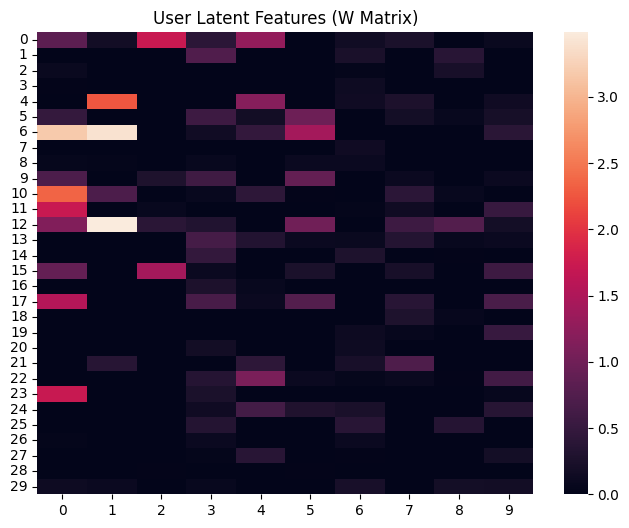

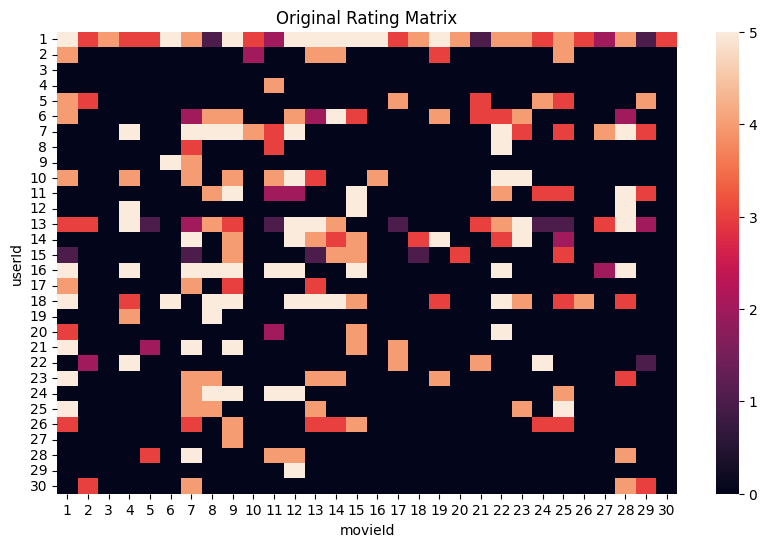

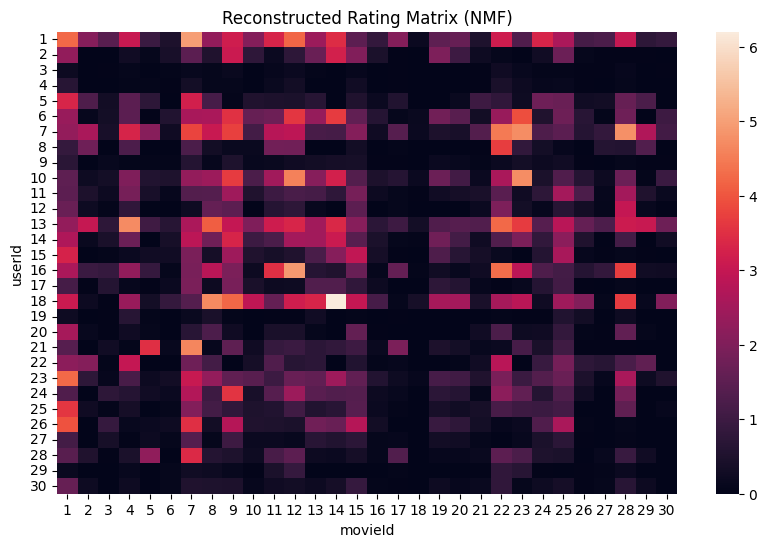

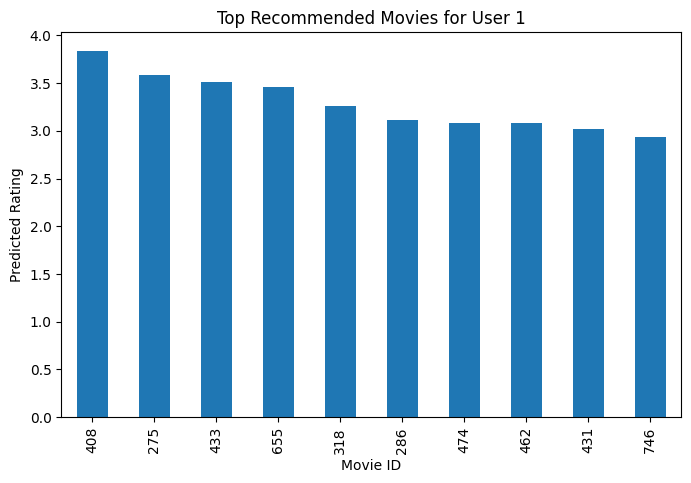

In [7]:
# SCENARIO 2 – MATRIX FACTORIZATION USING NMF

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# Load MovieLens Dataset
ratings = pd.read_csv(
    "u.data",
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)

ratings = ratings.drop("timestamp", axis=1)

# Create User-Item Matrix
user_item = ratings.pivot(
    index="userId",
    columns="movieId",
    values="rating"
)

# Handle Missing Values (fill with 0)
user_item_filled = user_item.fillna(0)

matrix = user_item_filled.values

# Apply NMF Model
k = 20
nmf_model = NMF(
    n_components=k,
    init="random",
    random_state=42,
    max_iter=200
)

# Factorization
W = nmf_model.fit_transform(matrix)   # User-feature matrix
H = nmf_model.components_             # Item-feature matrix

print("User Feature Matrix Shape:", W.shape)
print("Item Feature Matrix Shape:", H.shape)

# Reconstruct Rating Matrix
reconstructed = np.dot(W, H)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item.index,
    columns=user_item.columns
)

# Predict Missing Values & Recommendations
def recommend_movies(user_id, n=10):
    original_ratings = user_item.loc[user_id]
    predicted_ratings = reconstructed_df.loc[user_id]

    unseen_movies = original_ratings[original_ratings.isna()].index
    recommendations = predicted_ratings[unseen_movies] \
                        .sort_values(ascending=False) \
                        .head(n)

    return recommendations

print("\nTop Recommendations for User 1")
print(recommend_movies(1, 10))

# RMSE Evaluation (only known ratings)
mask = user_item.notna().values

rmse = np.sqrt(
    mean_squared_error(
        matrix[mask],
        reconstructed[mask]
    )
)

print("\nRMSE:", rmse)

# Precision@K and Recall@K
def precision_recall_at_k(k=10, threshold=4):
    precisions = []
    recalls = []

    for user in user_item.index:
        true_ratings = user_item.loc[user]
        preds = reconstructed_df.loc[user]

        relevant = true_ratings[true_ratings >= threshold].index
        recommended = preds.sort_values(ascending=False).head(k).index

        tp = len(set(recommended) & set(relevant))

        precision = tp / k if k > 0 else 0
        recall = tp / len(relevant) if len(relevant) > 0 else 0

        precisions.append(precision)
        recalls.append(recall)

    return np.mean(precisions), np.mean(recalls)

precision, recall = precision_recall_at_k(10)

print("Precision@10:", precision)
print("Recall@10:", recall)

# Visualization 1: Latent Feature Visualization
plt.figure(figsize=(8,6))
sns.heatmap(W[:30, :10])
plt.title("User Latent Features (W Matrix)")
plt.show()

# Visualization 2: Reconstruction Comparison
plt.figure(figsize=(10,6))
sns.heatmap(user_item_filled.iloc[:30, :30])
plt.title("Original Rating Matrix")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(reconstructed_df.iloc[:30, :30])
plt.title("Reconstructed Rating Matrix (NMF)")
plt.show()

# Visualization 3: Recommendation Ranking Chart
user_id = 1
top_movies = recommend_movies(user_id, 10)

plt.figure(figsize=(8,5))
top_movies.plot(kind="bar")
plt.title("Top Recommended Movies for User 1")
plt.xlabel("Movie ID")
plt.ylabel("Predicted Rating")
plt.show()